In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

Mounted at /content/drive


In [4]:
BASE_PATH   = "/content/drive/MyDrive/Emotion_Deception_Project"
DATA_PATH   = f"{BASE_PATH}/data/fer2013_processed.npz"
MODEL_H5    = f"{BASE_PATH}/models/emotion_model.h5"
MODEL_KERAS = f"{BASE_PATH}/models/emotion_model.keras"


In [5]:
data    = np.load(DATA_PATH)
X_train = data["X_train"]
y_train = data["y_train"]
X_test  = data["X_test"]
y_test  = data["y_test"]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (28709, 48, 48, 1), Test: (7178, 48, 48, 1)


In [6]:
y_ints       = np.argmax(y_train, axis=1)
class_counts = np.bincount(y_ints, minlength=7).astype(float)
class_weight = {i: len(y_ints) / (7 * c) for i, c in enumerate(class_counts)}
print("Class weights:", {i: f"{w:.2f}" for i, w in class_weight.items()})


Class weights: {0: '1.03', 1: '9.41', 2: '1.00', 3: '0.57', 4: '0.83', 5: '0.85', 6: '1.29'}


In [7]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
)
datagen.fit(X_train)


In [8]:
inp = layers.Input(shape=(48, 48, 1))


In [9]:
x = layers.Conv2D(32, (3,3), padding='same')(inp)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(32, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

In [10]:
x = layers.Conv2D(64, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(64, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

In [11]:
x = layers.Conv2D(128, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(128, (3,3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Dropout(0.25)(x)

In [12]:
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(7, activation='softmax')(x)

model = models.Model(inp, out, name="emotion_cnn_v2")
model.summary()

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "emotion_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 324,071 (1.24 MB)

 Trainable params: 322,663 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [13]:
cb_list = [
    callbacks.ModelCheckpoint(
        MODEL_H5,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        MODEL_KERAS,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
]

In [14]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    steps_per_epoch=len(X_train) // 64,
    epochs=50,
    validation_data=(X_test, y_test),
    class_weight=class_weight,
    callbacks=cb_list,
)


Epoch 1/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1602 - loss: 2.2290
Epoch 1: val_accuracy improved from None to 0.18236, saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 646s 1s/step - accuracy: 0.1673 - loss: 2.1328 - val_accuracy: 0.1824 - val_loss: 1.9105 - learning_rate: 0.0010
Epoch 2/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 10:29 1s/step - accuracy: 0.2031 - loss: 1.7656

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.18236
448/448 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.2031 - loss: 1.7656 - val_accuracy: 0.1789 - val_loss: 1.9093 - learning_rate: 0.0010
Epoch 3/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1819 - loss: 1.9962
Epoch 3: val_accuracy improved from 0.18236 to 0.21914, saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 605s 1s/step - accuracy: 0.1891 - loss: 1.9698 - val_accuracy: 0.2191 - val_loss: 2.2154 - learning_rate: 0.0010
Epoch 4/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 8:05 1s/step - accuracy: 0.1719 - loss: 1.6507
Epoch 4: val_accuracy improved from 0.21914 to 0.22235, saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5


...


Epoch 35: finished saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - accuracy: 0.5444 - loss: 1.1702 - val_accuracy: 0.5755 - val_loss: 1.1249 - learning_rate: 5.0000e-04
Epoch 36/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 8:16 1s/step - accuracy: 0.5156 - loss: 1.1054
Epoch 36: val_accuracy did not improve from 0.57551
448/448 ━━━━━━━━━━━━━━━━━━━━ 42s 92ms/step - accuracy: 0.5156 - loss: 1.1054 - val_accuracy: 0.5747 - val_loss: 1.1242 - learning_rate: 5.0000e-04
Epoch 37/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5502 - loss: 1.1495
Epoch 37: val_accuracy did not improve from 0.57551
448/448 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.5496 - loss: 1.1522 - val_accuracy: 0.5683 - val_loss: 1.1413 - learning_rate: 5.0000e-04
Epoch 38/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 8:30 1s/step - accuracy: 0.5312 - loss: 1.3480
Epoch 38: val_accuracy did not improve from 0.57551
448/448 ━━━━━━━━━━━━━━━━━━━━ 32s 6


Epoch 41: finished saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - accuracy: 0.5549 - loss: 1.1317 - val_accuracy: 0.5805 - val_loss: 1.1177 - learning_rate: 2.5000e-04
Epoch 42/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 9:58 1s/step - accuracy: 0.6719 - loss: 1.0220
Epoch 42: val_accuracy improved from 0.58052 to 0.58094, saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5



Epoch 42: finished saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 43s 94ms/step - accuracy: 0.6719 - loss: 1.0220 - val_accuracy: 0.5809 - val_loss: 1.1161 - learning_rate: 2.5000e-04
Epoch 43/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5636 - loss: 1.1002
Epoch 43: val_accuracy did not improve from 0.58094
448/448 ━━━━━━━━━━━━━━━━━━━━ 638s 1s/step - accuracy: 0.5631 - loss: 1.1021 - val_accuracy: 0.5808 - val_loss: 1.1186 - learning_rate: 2.5000e-04
Epoch 44/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 10:11 1s/step - accuracy: 0.6250 - loss: 0.9114
Epoch 44: val_accuracy improved from 0.58094 to 0.58164, saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5



Epoch 44: finished saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 43s 94ms/step - accuracy: 0.6250 - loss: 0.9114 - val_accuracy: 0.5816 - val_loss: 1.1174 - learning_rate: 2.5000e-04
Epoch 45/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5622 - loss: 1.1021
Epoch 45: val_accuracy did not improve from 0.58164
448/448 ━━━━━━━━━━━━━━━━━━━━ 629s 1s/step - accuracy: 0.5652 - loss: 1.0973 - val_accuracy: 0.5747 - val_loss: 1.1342 - learning_rate: 2.5000e-04
Epoch 46/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 8:29 1s/step - accuracy: 0.5469 - loss: 1.1155
Epoch 46: val_accuracy did not improve from 0.58164

Epoch 46: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
448/448 ━━━━━━━━━━━━━━━━━━━━ 42s 92ms/step - accuracy: 0.5469 - loss: 1.1155 - val_accuracy: 0.5759 - val_loss: 1.1340 - learning_rate: 2.5000e-04
Epoch 47/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5712 - loss: 1.0879
Epoch 47:


Epoch 47: finished saving model to /content/drive/MyDrive/Emotion_Deception_Project/models/emotion_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 633s 1s/step - accuracy: 0.5700 - loss: 1.0808 - val_accuracy: 0.5977 - val_loss: 1.0826 - learning_rate: 1.2500e-04
Epoch 48/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 10:05 1s/step - accuracy: 0.6250 - loss: 0.8782
Epoch 48: val_accuracy did not improve from 0.59766
448/448 ━━━━━━━━━━━━━━━━━━━━ 42s 92ms/step - accuracy: 0.6250 - loss: 0.8782 - val_accuracy: 0.5967 - val_loss: 1.0838 - learning_rate: 1.2500e-04
Epoch 49/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5798 - loss: 1.0621
Epoch 49: val_accuracy did not improve from 0.59766
448/448 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.5756 - loss: 1.0752 - val_accuracy: 0.5936 - val_loss: 1.0772 - learning_rate: 1.2500e-04
Epoch 50/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 13:11 2s/step - accuracy: 0.6094 - loss: 0.9025
Epoch 50: val_accuracy did not improve from 0.59766
448/448 ━━━━━━━━━━━━━━━━━━━━ 43s

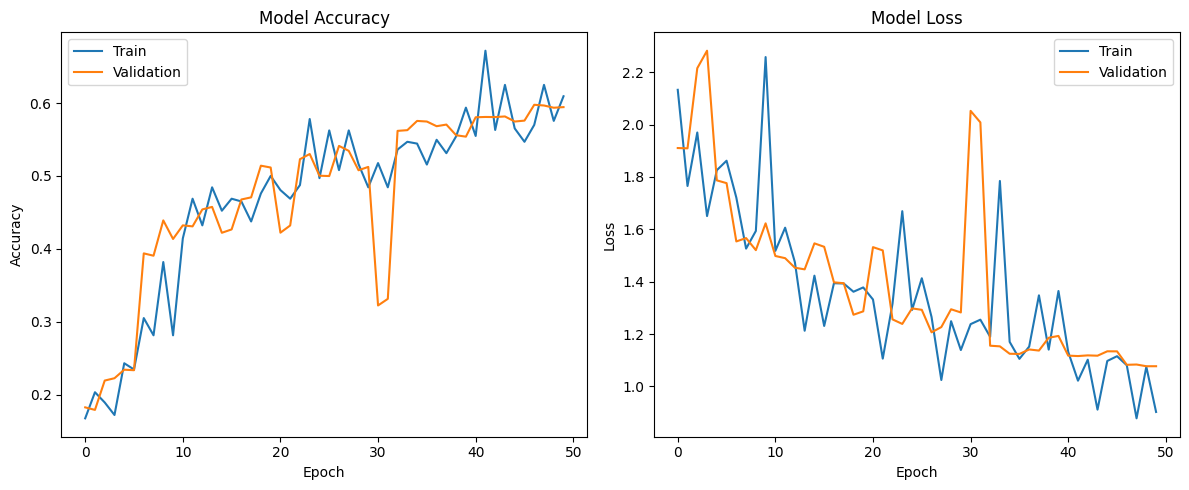

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/outputs/training_curves.png", dpi=120)
plt.show()

In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")


225/225 ━━━━━━━━━━━━━━━━━━━━ 31s 139ms/step - accuracy: 0.5936 - loss: 1.0772

Test Accuracy: 0.5936 (59.4%)


In [17]:
import tensorflow as tf

# Should print: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
print(tf.config.list_physical_devices('GPU'))

# Should NOT be empty
gpu = tf.test.gpu_device_name()
print("GPU:", gpu if gpu else "❌ No GPU — switch runtime!")

[]
GPU: ❌ No GPU — switch runtime!
